In [ ]:
import pathlib

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn

from IPython.display import HTML, display
from pprint import pprint


import src.visuals as visual
import src.utils as utils

from src.models import PINN
from src.loss import NavierStokesLoss
from src.dataloader import load_data, gen_dataloaders
from src.train import train_model

%load_ext autoreload
%autoreload 2


In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

file_name = "data"
data_path = pathlib.Path("data")

train_df, valid_df, test_df = load_data(data_path, file_name)

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,344064.0000,344064.000000,344064.000000,344064.000000,344064.000000,344064.000000,344064.000000
mean,0.2000,566.399417,0.044181,0.050000,0.000050,0.013588,-6.279878
std,0.1633,235.592793,0.028746,0.028864,0.591035,0.476494,34.953660
min,0.0000,136.734694,0.000541,0.000781,-7.330010,-8.056250,-413.839000
25%,0.0000,384.693878,0.019156,0.025391,-0.069758,-0.000097,-0.049698
50%,0.2000,568.367347,0.041292,0.050000,-0.002578,0.000000,-0.000467
75%,0.4000,747.448980,0.067615,0.074609,0.000000,0.041508,0.000000
max,0.4000,1000.000000,0.098918,0.099219,19.695500,9.433480,26.351400


In [5]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,122880.0000,122880.000000,122880.000000,122880.000000,122880.000000,122880.000000,122880.000000
mean,0.2000,640.000000,0.044181,0.050000,0.000057,0.012146,-0.016199
std,0.1633,205.386871,0.028746,0.028864,0.168268,0.107363,0.106263
min,0.0000,338.775510,0.000541,0.000781,-0.237117,-0.518394,-5.072000
25%,0.0000,448.979592,0.019156,0.025391,-0.066012,0.000000,-0.030944
50%,0.2000,614.285714,0.041292,0.050000,-0.003468,0.000000,0.000000
75%,0.4000,816.326531,0.067615,0.074609,0.000000,0.040490,0.000000
max,0.4000,981.632653,0.098918,0.099219,0.954053,0.338418,4.201350


In [6]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,98304.0000,98304.000000,98304.000000,98304.000000,98304.000000,98304.000000,98304.000000
mean,0.2000,954.081633,0.044225,0.050000,0.000015,0.011317,-2.840565
std,0.1633,9.183720,0.028751,0.028867,0.173120,0.125971,2.932561
min,0.0000,944.897959,0.000271,0.000391,-0.436891,-0.587446,-14.927000
25%,0.0000,944.897959,0.019038,0.025195,-0.077317,-0.002014,-5.939380
50%,0.2000,954.081633,0.041356,0.050000,0.000000,0.000000,-1.282835
75%,0.4000,963.265306,0.067897,0.074805,0.000000,0.059553,0.000000
max,0.4000,963.265306,0.099459,0.099609,1.140830,1.477360,2.264850


In [8]:
mean = train_df.mean()
std = train_df.std()

train_df = utils.normalize_data(train_df, mean, std)
valid_df = utils.normalize_data(valid_df, mean, std)
test_df = utils.normalize_data(test_df, mean, std)

In [9]:
train_dataloader, valid_dataloader, test_dataloader = gen_dataloaders(train_df, valid_df, test_df, input_col_names, target_col_names)

In [10]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(0.1)
optimizer = torch.optim.Adam(model.parameters())

EPOCHS = 20

In [12]:
train_losses, valid_losses = train_model(model, train_dataloader, valid_dataloader, criterion, optimizer, device, EPOCHS, physics_loss=True)

  9%|▉         | 120/1344 [00:30<05:13,  3.91it/s]


KeyboardInterrupt: 

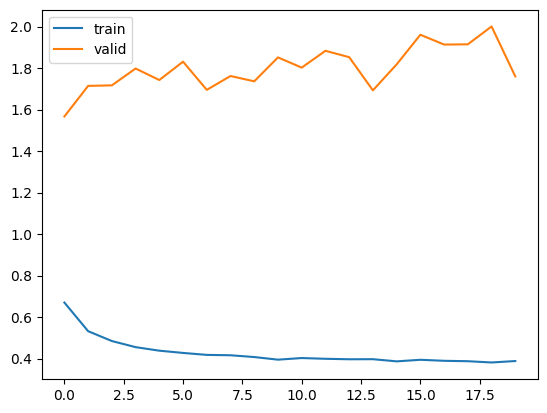

In [78]:
plt.plot(train_losses, label="train")
plt.plot(valid_losses, label="valid")
plt.legend()

In [11]:
# Učitaj originalne nenormalizovane podatke za vizuelizaciju i evaluaciju
file_name = "data"
data_path = pathlib.Path("data")

train_df_original, valid_df_original, test_df_original = load_data(data_path, file_name)

print(f"Train skup: {train_df_original.shape[0]} redova")
print(f"Valid skup: {valid_df_original.shape[0]} redova")
print(f"Test skup: {test_df_original.shape[0]} redova")
print(f"\nVremenske korake: {sorted(train_df_original['time'].unique())}")
print(f"Reynolds brojevi: {sorted(train_df_original['re'].unique())}")

Train skup: 344064 redova
Valid skup: 122880 redova
Test skup: 98304 redova

Vremenske korake: [np.float64(0.0), np.float64(0.2), np.float64(0.4)]
Reynolds brojevi: [np.float64(136.73469387755102), np.float64(191.8367346938776), np.float64(228.57142857142856), np.float64(265.30612244897964), np.float64(283.6734693877551), np.float64(302.0408163265306), np.float64(357.1428571428572), np.float64(393.8775510204082), np.float64(430.6122448979592), np.float64(467.34693877551024), np.float64(485.7142857142858), np.float64(504.08163265306126), np.float64(522.4489795918367), np.float64(540.8163265306123), np.float64(595.9183673469388), np.float64(614.2857142857143), np.float64(632.6530612244899), np.float64(669.3877551020408), np.float64(706.1224489795919), np.float64(724.4897959183675), np.float64(742.8571428571429), np.float64(761.2244897959184), np.float64(797.9591836734694), np.float64(834.6938775510205), np.float64(871.4285714285716), np.float64(889.795918367347), np.float64(908.163265306

In [12]:
# Učitaj originalne nenormalizovane podatke za vizuelizaciju
file_name = "data"
data_path = pathlib.Path("data")

train_df_original, valid_df_original, test_df_original = load_data(data_path, file_name)

print(f"Train skup: {train_df_original.shape[0]} redova")
print(f"Test skup: {test_df_original.shape[0]} redova")
print(f"\nVremenske korake: {sorted(train_df_original['time'].unique())}")
print(f"Reynolds brojevi: {sorted(train_df_original['re'].unique())}")

Train skup: 344064 redova
Test skup: 98304 redova

Vremenske korake: [np.float64(0.0), np.float64(0.2), np.float64(0.4)]
Reynolds brojevi: [np.float64(136.73469387755102), np.float64(191.8367346938776), np.float64(228.57142857142856), np.float64(265.30612244897964), np.float64(283.6734693877551), np.float64(302.0408163265306), np.float64(357.1428571428572), np.float64(393.8775510204082), np.float64(430.6122448979592), np.float64(467.34693877551024), np.float64(485.7142857142858), np.float64(504.08163265306126), np.float64(522.4489795918367), np.float64(540.8163265306123), np.float64(595.9183673469388), np.float64(614.2857142857143), np.float64(632.6530612244899), np.float64(669.3877551020408), np.float64(706.1224489795919), np.float64(724.4897959183675), np.float64(742.8571428571429), np.float64(761.2244897959184), np.float64(797.9591836734694), np.float64(834.6938775510205), np.float64(871.4285714285716), np.float64(889.795918367347), np.float64(908.1632653061224), np.float64(1000.0)]

Dostupni Reynolds brojevi: [np.float64(136.73469387755102), np.float64(191.8367346938776), np.float64(228.57142857142856), np.float64(265.30612244897964), np.float64(283.6734693877551)]... (ukupno 28)
Dostupni vremenske korake: [np.float64(0.0), np.float64(0.2), np.float64(0.4)]


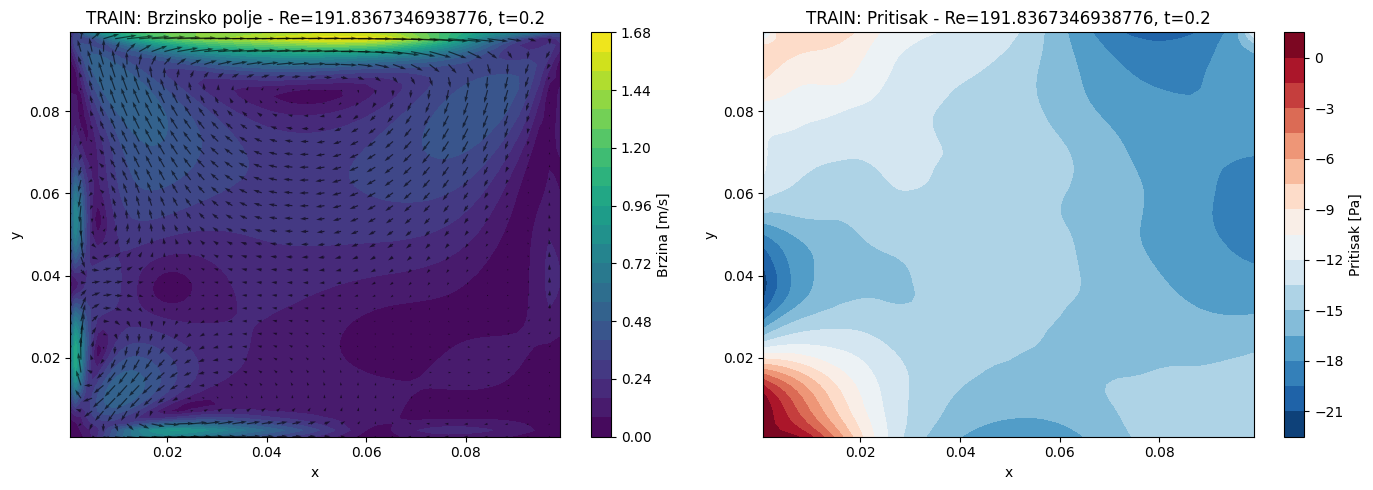

In [13]:
# Primjer: vizuelizacija train skupa
re_values = sorted(train_df_original['re'].unique())
time_steps = sorted(train_df_original['time'].unique())

print(f"Dostupni Reynolds brojevi: {re_values[:5]}... (ukupno {len(re_values)})")
print(f"Dostupni vremenske korake: {time_steps}")

# Vizuelizuj prvi Reynolds broj na prvom vremenskom koraku
visual.plot_velocity_and_pressure(train_df_original, time_steps[1], re_values[1], "TRAIN:")

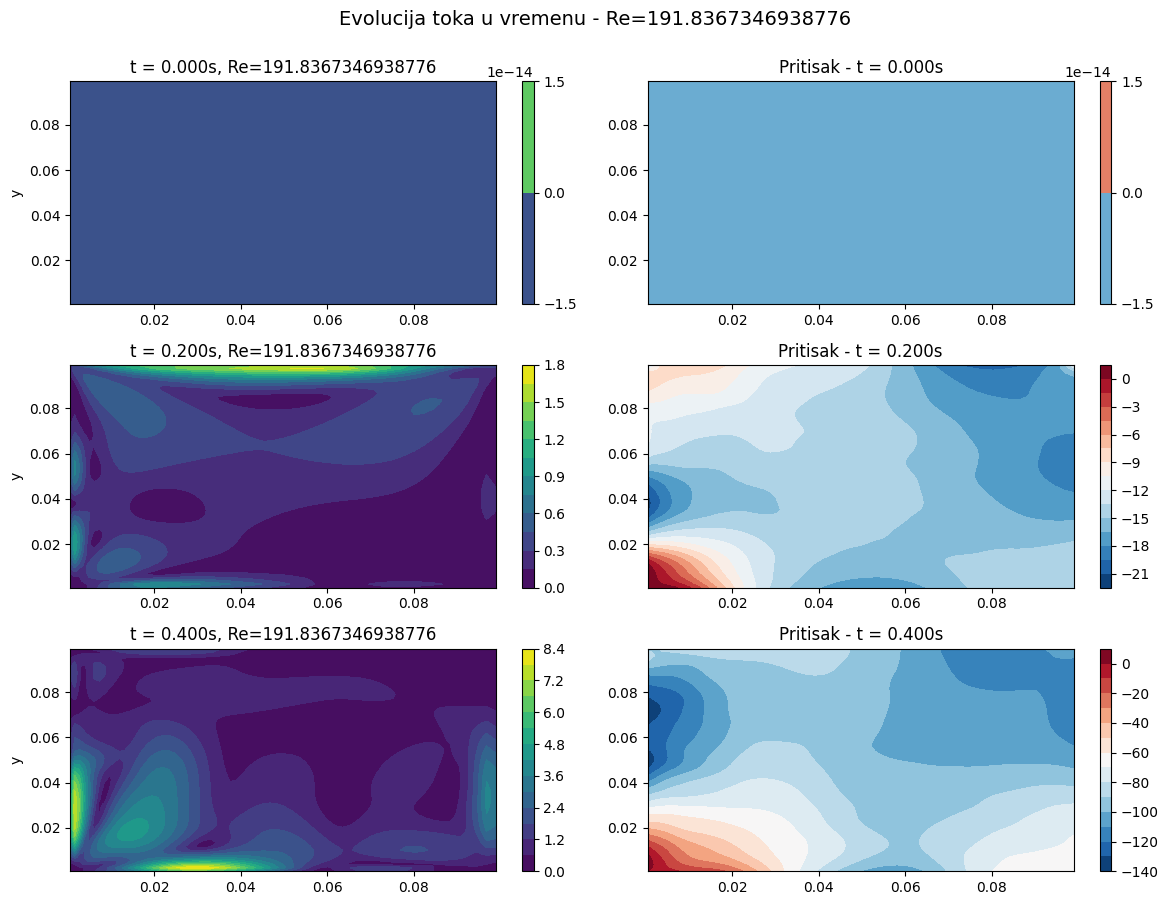

In [26]:
# Vizuelizacija evolucije kroz vrijeme za fiksni Reynolds broj
visual.plot_evolution_in_time(train_df_original, re_values[1])

MAE U_x: 0.099913
MAE U_y: 0.052762
MAE p: 5.884275


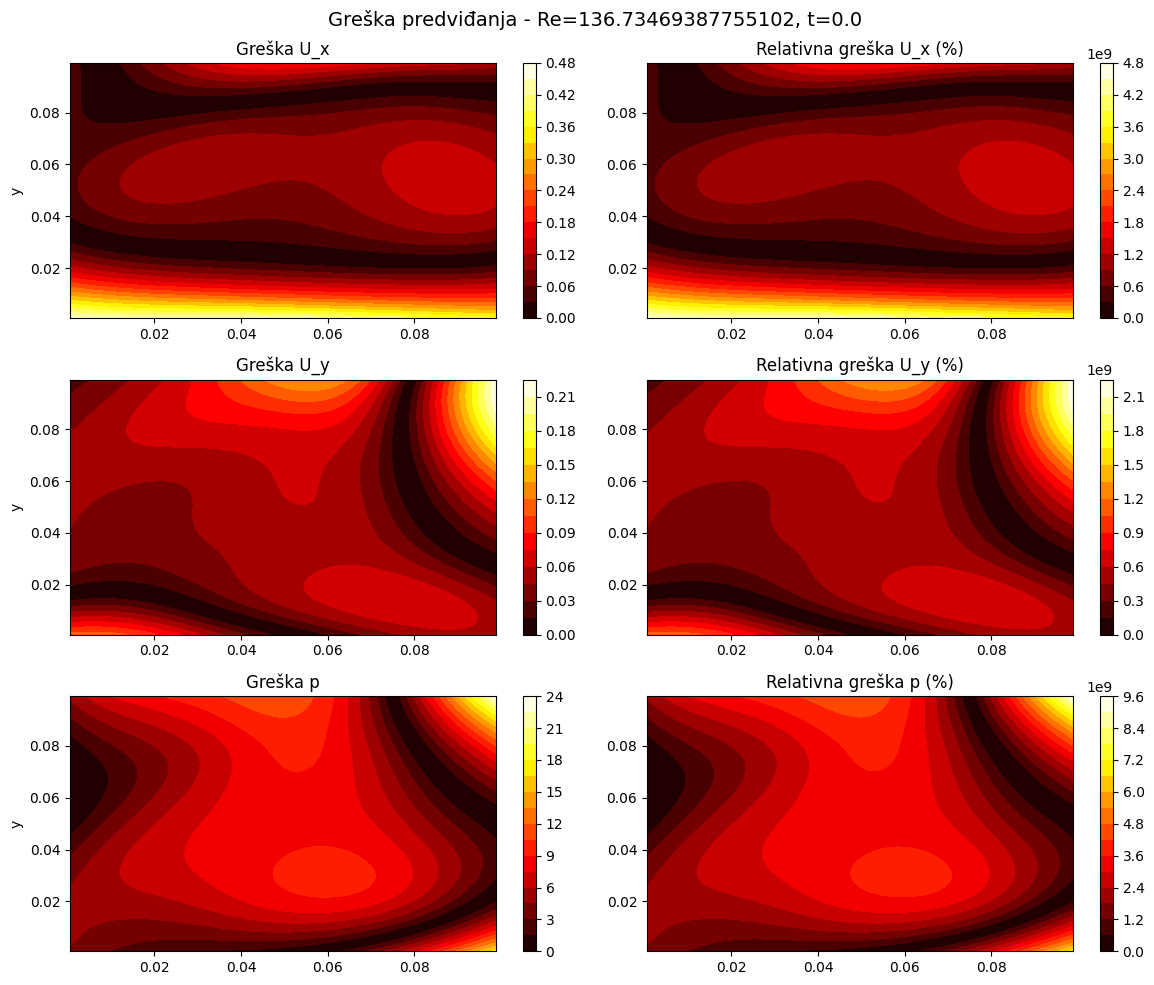

In [30]:
# Poređenje predviđanja modela sa stvarnim podacima
mean = train_df.mean()
std = train_df.std()
visual.compare_predictions(model, train_df_original, time_steps[0], re_values[0], mean, std, device)

MAE U_x: 0.034514
MAE U_y: 0.028851
MAE p: 0.543416


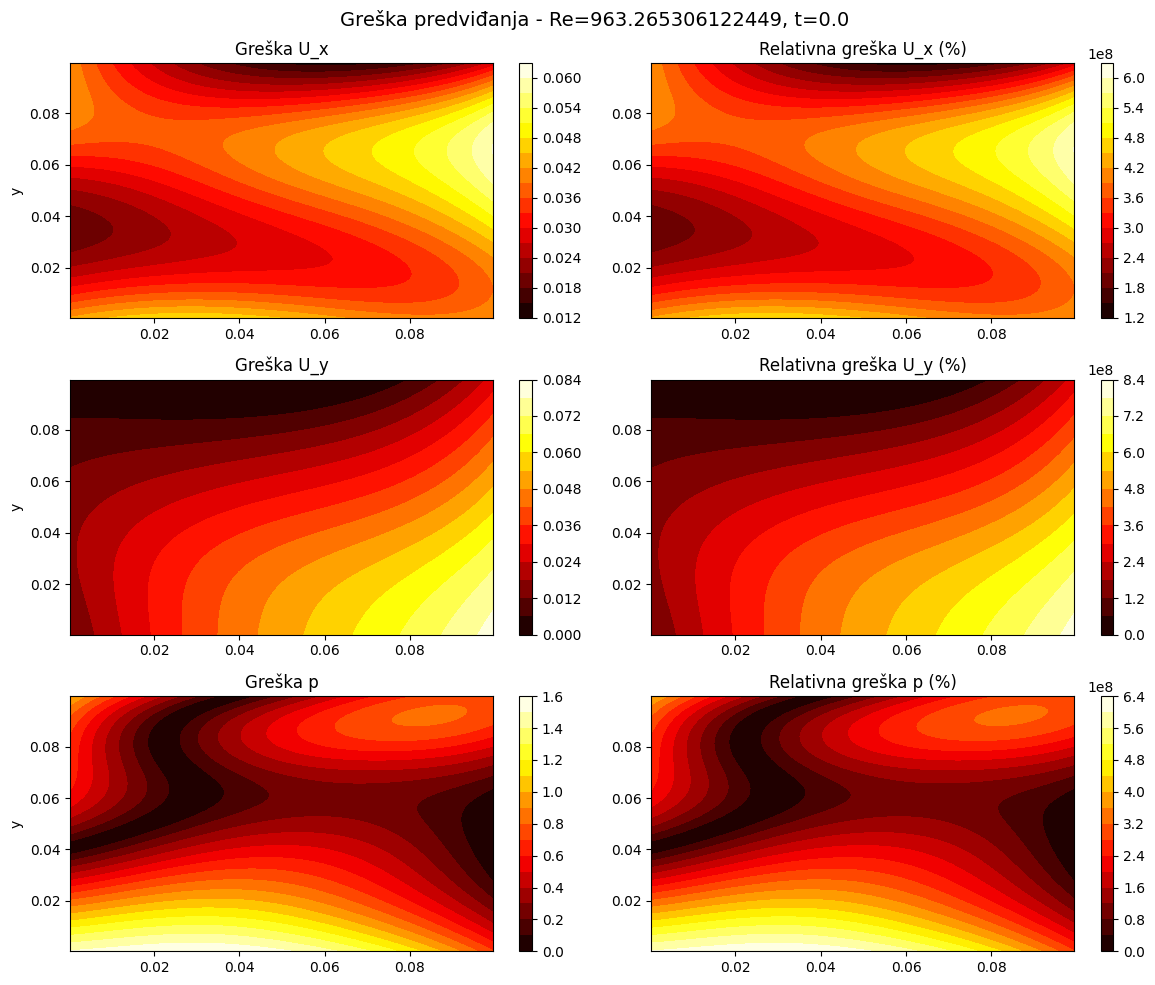

MAE U_x: 0.032696
MAE U_y: 0.028243
MAE p: 0.542688


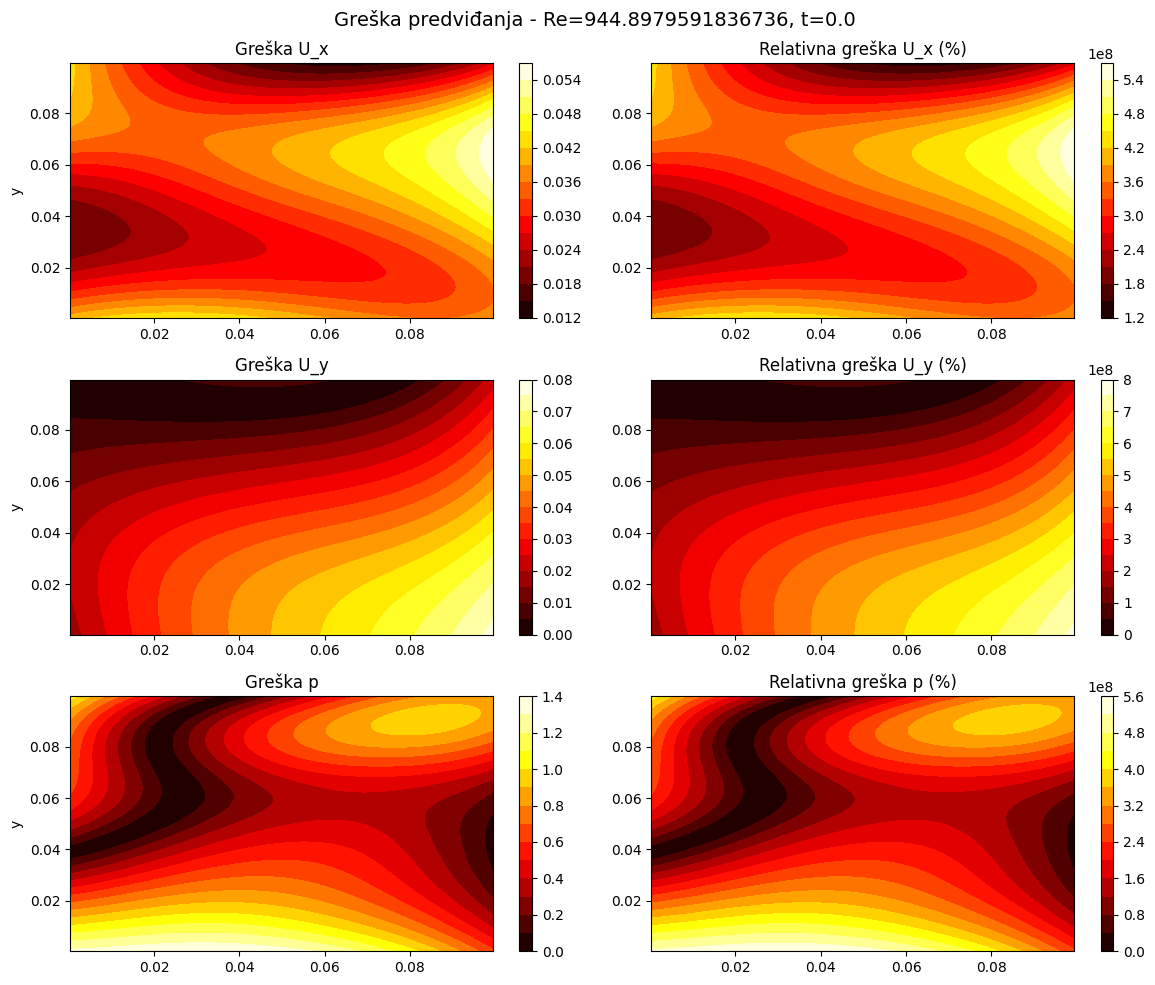

In [31]:
visual.evaluate_on_test_set(model, test_df_original, mean, std, device, num_samples=5)

In [ ]:
# Full evaluation summary for all splits

split_dfs = {
    "valid": valid_df_original,
    "test": test_df_original,
}

for split_name, split_df in split_dfs.items():
    print(f"\n{'=' * 60}")
    print(f"{split_name.upper()} EVALUATION")
    print(f"{'=' * 60}")

    data_metrics = utils.evaluate_model(
        model=model,
        df=split_df,
        input_col_names=input_col_names,
        target_col_names=target_col_names,
        mean=mean,
        std=std,
        device=device,
    )

    print(f"\nSamples: {len(split_df)}")
    print("\nSupervised metrics (original scale):")
    pprint(data_metrics)


TRAIN EVALUATION


In [32]:
visual.animate_flow(train_df_original, re_values[0], output_file="flow_animation.gif", fps=3)

Generiši 3 frame-ova...


/mnt2/ml_projekat/PINN-for-Simulating-2D-Incompressible-Fluid-Dynamics/pinn_env/lib/python3.12/site-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/mnt2/ml_projekat/PINN-for-Simulating-2D-Incompressible-Fluid-Dynamics/pinn_env/lib/python3.12/site-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


  ✓ 1/3 frame-ova generirano
  ✓ 2/3 frame-ova generirano
  ✓ 3/3 frame-ova generirano

Kombinujem slike u GIF (flow_animation.gif)...
✓ GIF spreman: flow_animation.gif
  • Frejmova: 3
  • Brzina: 3 fps
  • Trajanje: 1.0s


'flow_animation.gif'

Generiši 3 frame-ova greške...
  ✓ 1/3 frame-ova generisano
  ✓ 2/3 frame-ova generisano
  ✓ 3/3 frame-ova generisano

Kombinujem slike u GIF (error_animation.gif)...
✓ GIF greške spreman: error_animation.gif
  • Frejmova: 3
  • Brzina: 2 fps
  • Trajanje: 1.5s


'error_animation.gif'

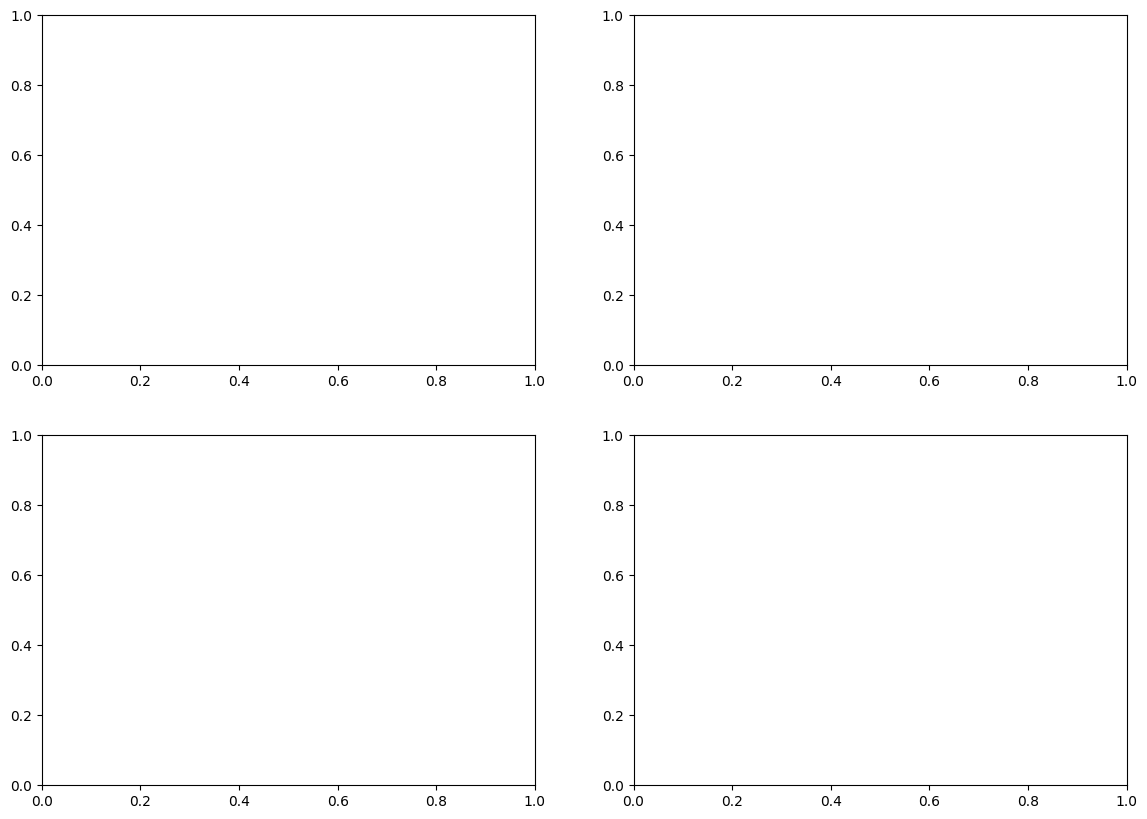

In [33]:
visual.animate_error(model, train_df_original, re_values[0], mean, std, device, fps=2, output_file="error_animation.gif")